<a href="https://colab.research.google.com/github/SriSharanya-617/deeplearning/blob/main/tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Diabetes Risk Prediction (Using TensorFlow Framework)

Neural Network Architecture:

2 Inputs -+ 3 Hidden Neurons (Sigmoid) -+ 1 Output (Sigmoid)
Output = 1- High Risk Output = O - Low Risk

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [3]:
X=np.array([
[120,25],
[85,30],
[150,35],
[95,22]

])

X=X/200
Y=np.array([1,0,1,0])

print("Input Shape:",X.shape)
print("Output Shape:",Y.shape)


Input Shape: (4, 2)
Output Shape: (4,)


build neural network model

In [6]:
model=Sequential([
  Dense(3,input_shape=(2,), activation='sigmoid'), # Hidden Layer
  Dense(1,activation='sigmoid')
]) # Output Layer
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

compile the model

In [7]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

train the model

In [8]:
model.fit(X,Y,epochs=500,verbose=0)

make predictions

In [9]:
predictions=model.predict(X)
print("Predictions:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predictions:
[[0.4998669 ]
 [0.49955416]
 [0.51034856]
 [0.49491352]]


Setosa 2 Versicolor

Goal:

Predict which flower species an iris belongs to.

Classes:

1

3

Virginica

TT B I <> G

Input Layer (4 neurons)

Hidden Layer (10 neurons, ReLU)

Hidden Layer (5 neurons, ReLU)

Output Layer (3 neurons, Softmax)


In [10]:
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import argmax
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


In [13]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names=iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


In [14]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [16]:
#Defin the Model Architecture
model=Sequential()
model.add(Dense(10, activation='relu', input_shape=(X_train.shape[1], )))
model.add(Dense(5,activation='relu'))
model.add(Dense(3,activation='softmax'))
model. summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy' ])

In [19]:
test_loss, test_accuracy=model.evaluate(X_test, y_test)
print(f'Test Accuracy: ', test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.4333 - loss: 1.0267
Test Accuracy:  0.4333333373069763


In [21]:
#Make Predictions
y_pred_proba=model.predict(X_test) # [[0.98 0.01 0.01][0.02 0.94 0.04]]
y_pred=argmax(y_pred_proba, axis=1) # Argmax selects the highest probability. [0.98 0.01 0.01] + class 0

#Calculate Accuracy
accuracy=accuracy_score(y_test,y_pred)
print(f'Test Accuracy: {accuracy}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Test Accuracy: 0.43333333333333335


In [28]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
path='/content/drive/MyDrive/Colab Notebooks/CarPrice_dataset.csv'
df=pd.read_csv(path)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [41]:
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import argmax
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

In [44]:
df.isna().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [33]:
df = df.dropna()

In [34]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [35]:
df = df.drop_duplicates()

In [36]:
df["price"] = df["price"].astype(float)

In [37]:
X = df.drop("price", axis=1)
y = df["price"]

In [38]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

In [46]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))   # regression output

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [48]:
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - loss: 220710080.0000 - val_loss: 317937568.0000
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 210729904.0000 - val_loss: 317926112.0000
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 213434112.0000 - val_loss: 317913856.0000
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 215020544.0000 - val_loss: 317900192.0000
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 193651440.0000 - val_loss: 317884096.0000
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step - loss: 203634912.0000 - val_loss: 317863904.0000
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - loss: 237103552.0000 - val_loss: 317837792.0000
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - loss: 213981024.0000 - val_loss: 317806112.0000
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 206905344.0000 - val_loss: 317766304.0000
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 219030000.0000 - val_loss: 317717408.0000
Ep

In [50]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2 Score:", r2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
RMSE: 15388.264224560611
R2 Score: -1.9995770826756858


In [51]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [53]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - loss: 225524560.0000 - mae: 12981.2842 - val_loss: 317942016.0000 - val_mae: 15082.9834
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 232547312.0000 - mae: 13310.0967 - val_loss: 317929824.0000 - val_mae: 15082.6357
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 221364528.0000 - mae: 12953.8086 - val_loss: 317916640.0000 - val_mae: 15082.2607
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 208148960.0000 - mae: 12555.6553 - val_loss: 317901920.0000 - val_mae: 15081.8330
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 210866032.0000 - mae: 12865.2568 - val_loss: 317884544.0000 - val_mae: 15081.3350
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 210171072.0000 - mae: 12749.2529 - val_loss: 317863264.0000 - val_mae: 15080.7295
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 211264048.0000 - mae: 12769.9355 - val_loss: 317837280.0000 - val_mae: 15079.9893
Epoch 8/100
5/5 ━━━

In [54]:
predictions = model.predict(X_test)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


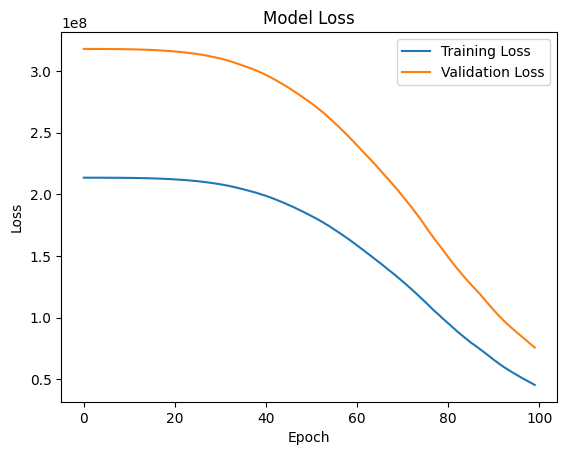

In [55]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()